In [ ]:
# Assignment Data 1200 – SVM and Naïve Bayes

In [1]:
#Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [6]:
#Load Dataset
raisin=pd.read_csv('./Raisin_Dataset.csv')
raisin.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [5]:
#Key Statistics
raisin.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,75776.400000,385.987015,252.447897,0.733780,78370.200000,0.714553,1086.362800
std,17817.747692,66.695095,30.264059,0.108844,18416.275077,0.061506,145.399972
min,45928.000000,286.540559,208.760042,0.564011,47336.000000,0.637613,844.162000
25%,75166.000000,352.190770,243.032436,0.684989,78789.000000,0.684130,1073.251000
50%,79408.000000,406.690687,253.291155,0.798354,81463.000000,0.699599,1121.786000
75%,87524.000000,442.246011,266.328318,0.801805,90546.000000,0.758651,1184.040000
max,90856.000000,442.267048,290.827533,0.819738,93717.000000,0.792772,1208.575000


<Axes: >

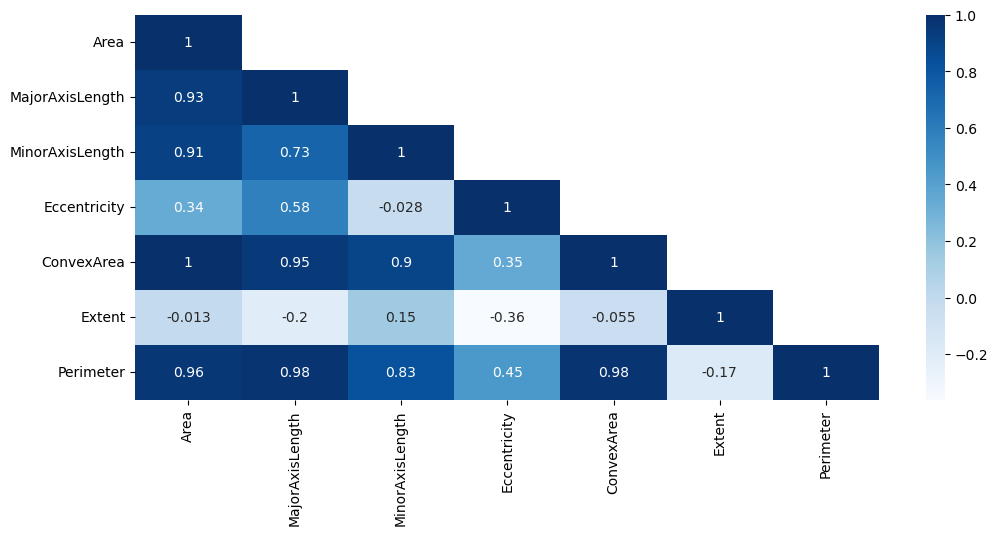

In [12]:
#Visualization of Correlations
fig = plt.figure(figsize=(12,5))
raisin_df=raisin.select_dtypes(include='number')
sns.heatmap(raisin_df.corr(),annot=True,cmap="Blues",mask=np.triu(raisin_df.corr(),+1))

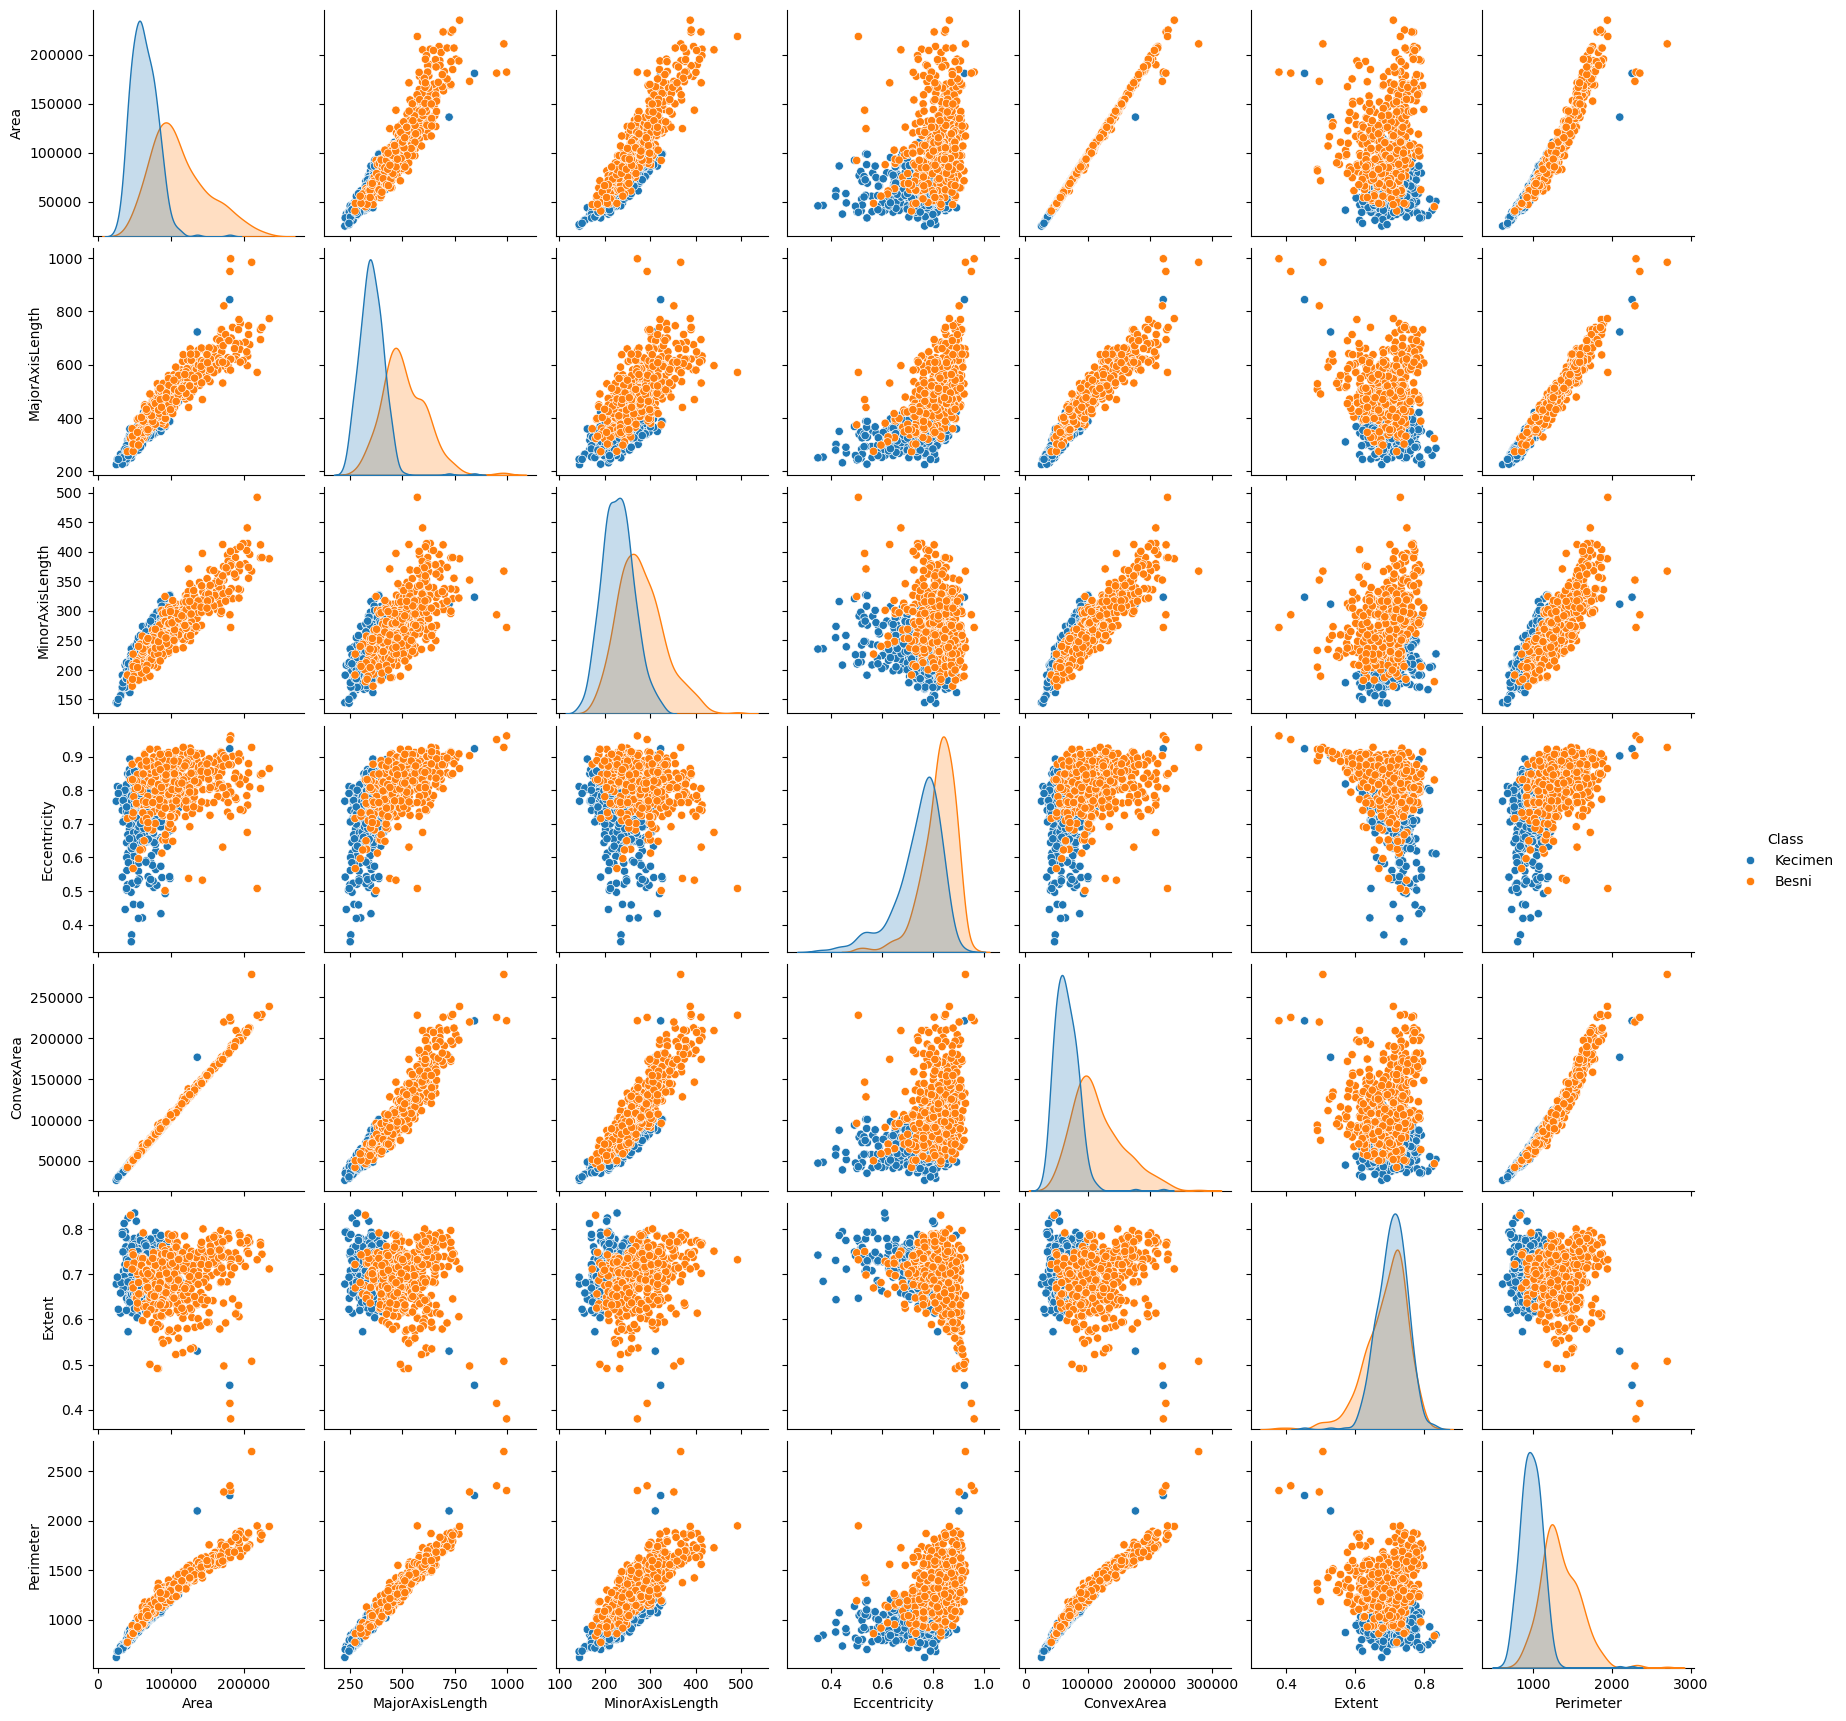

In [15]:
# Pairplot with hue=species
sns.pairplot(raisin, hue ='Class')

In [17]:
#Create x and y variables
x=raisin.drop('Class', axis=1).to_numpy()
y=raisin['Class'].to_numpy()

#Create Training and Test Datasets
from sklearn.model_selection import train_test_split
x_train, x_test,y_train, y_test = train_test_split(x, y, stratify=y,test_size=0.2,random_state=100)

#Scale the Data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train2 = sc.fit_transform(x_train)
x_test2 = sc.transform(x_test)

In [22]:
#Script for SVM and NB
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix  

for name,method in [('SVM', SVC(random_state=100)),
                    ('Naive Bayes',GaussianNB())]: 
    method.fit(x_train2,y_train)
    predict = method.predict(x_test2)
    target_names=['Kecimen','Besni']

    # Confusion Matrix with labels
    cm = confusion_matrix(y_test,predict)
    cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
    print('\n### Estimator: {} ###'.format(name)) 
    print("Confusion Matrix:")
    print(cm_df)
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test,predict,target_names=target_names))  


### Estimator: SVM ###
Confusion Matrix:
         Kecimen  Besni
Kecimen       74     16
Besni          8     82

Classification Report:
              precision    recall  f1-score   support

     Kecimen       0.90      0.82      0.86        90
       Besni       0.84      0.91      0.87        90

    accuracy                           0.87       180
   macro avg       0.87      0.87      0.87       180
weighted avg       0.87      0.87      0.87       180


### Estimator: Naive Bayes ###
Confusion Matrix:
         Kecimen  Besni
Kecimen       67     23
Besni          7     83

Classification Report:
              precision    recall  f1-score   support

     Kecimen       0.91      0.74      0.82        90
       Besni       0.78      0.92      0.85        90

    accuracy                           0.83       180
   macro avg       0.84      0.83      0.83       180
weighted avg       0.84      0.83      0.83       180

